In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Configuración de estilo de gráficos
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Constantes Físicas
# hbar * c en unidades de [GeV * mm]
# hbar = 6.582e-25 GeV s
# c = 2.998e8 m/s = 2.998e11 mm/s
# hbar*c approx 1.973e-13 GeV*mm
HBAR_C_MM = 1.973269804e-13 

# Directorios
INPUT_DIR = "scan_results_nightly"
OUTPUT_DIR = "analysis_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"[INIT] Configuración lista. Buscando datos en {INPUT_DIR}...")

[INIT] Configuración lista. Buscando datos en scan_results_nightly...


Carga de datos

In [5]:
# 1. Identificar archivos
all_files = glob.glob(f"{INPUT_DIR}/**/*.csv", recursive=True)
print(f"[INFO] Se encontraron {len(all_files)} archivos CSV.")

# 2. Definir columnas a cargar (Basado en tu output real)
cols_to_load = [
    "m_phi", "tan_beta", "lam1", "sin_ba",
    "positivity_ok", "unitarity_ok", "perturbativity_ok",
    "total_width", "br_gaga", "width_gaga"
]

# 3. Cargar y concatenar
df_list = []
for filename in all_files:
    try:
        # Cargamos solo lo necesario
        #df_tmp = pd.read_csv(filename, usecols=cols_to_load)
        df_tmp = pd.read_csv(filename)
        df_list.append(df_tmp)
    except Exception as e:
        print(f"[WARN] Error leyendo {filename}: {e}")

if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print(f"[OK] Total de puntos crudos cargados: {len(df)}")
else:
    print("[ERROR] No se pudieron cargar datos.")

[INFO] Se encontraron 24 archivos CSV.
[OK] Total de puntos crudos cargados: 7702950


## Filtrado y calculo de $c\tau$

In [ ]:
# 1. Filtro Teórico (Triple OK)
mask_valid = (
    (df["positivity_ok"] == 1) & 
    (df["unitarity_ok"] == 1) & 
    (df["perturbativity_ok"] == 1)
)
df_valid = df[mask_valid].copy()

n_valid = len(df_valid)
eff = n_valid / len(df) * 100 if len(df) > 0 else 0
print(f"[INFO] Puntos válidos (TripleOK): {n_valid} ({eff:.2f}%)")

del(df)  # Liberar memoria

# 2. Cálculo de ctau [mm]
# ctau = (hbar * c) / Gamma_tot
# Evitamos división por cero reemplazando 0 con un epsilon muy pequeño
df_valid["ctau_mm"] = HBAR_C_MM / df_valid["total_width"].replace(0, 1e-99)

df_valid["br_bb"] = df_valid["width_bb"] / df_valid["total_width"].replace(0, 1e-99)



NameError: name 'df' is not defined

In [10]:

# 3. Preview
print("\nPrimeras filas del dataset válido:")
display(df_valid[["m_phi", "tan_beta", "lam1", "total_width","width_bb","br_bb","width_gaga", "br_gaga", "ctau_mm"]].head())


Primeras filas del dataset válido:


,m_phi,tan_beta,lam1,total_width,width_bb,br_bb,width_gaga,br_gaga,ctau_mm
3448539,290.0,30000.0,8.147615,3.321056e-10,4.932404e-12,0.014852,2.066248e-10,0.622166,0.000594
3448540,290.0,30000.0,8.148815,1.484642e-10,4.130528e-12,0.027822,1.007241e-10,0.678440,0.001329
3448541,290.0,30000.0,8.150015,1.484644e-10,4.130528e-12,0.027822,1.007242e-10,0.678440,0.001329
3448542,290.0,30000.0,8.151215,1.484645e-10,4.130528e-12,0.027822,1.007243e-10,0.678440,0.001329
3448543,290.0,30000.0,8.152415,1.484646e-10,4.130528e-12,0.027822,1.007244e-10,0.678440,0.001329


In [7]:
# Seleccionar un slice de masa para visualizar tendencias limpias
m_target = 200.0
tol = 1.0
subset = df_valid[ 
    (df_valid["m_phi"] > m_target - tol) & 
    (df_valid["m_phi"] < m_target + tol) 
]

if not subset.empty:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Eje Izquierdo: BR (Rojo)
    color = 'tab:red'
    ax1.set_xlabel(r'$\tan\beta$', fontsize=14)
    ax1.set_ylabel(r'BR($H \to \gamma\gamma$)', color=color, fontsize=14)
    # Scatter con alpha bajo para ver densidad
    ax1.scatter(subset["tan_beta"], subset["br_gaga"], color=color, alpha=0.3, label='Branching Ratio', s=10)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xscale('log')
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    
    # Línea de referencia BR=0.9
    ax1.axhline(0.9, color='darkred', linestyle='--', alpha=0.5)

    # Eje Derecho: ctau (Azul)
    ax2 = ax1.twinx() 
    color = 'tab:blue'
    ax2.set_ylabel(r'$c\tau$ [mm]', color=color, fontsize=14)
    ax2.scatter(subset["tan_beta"], subset["ctau_mm"], color=color, marker='x', alpha=0.3, label='Decay Length', s=10)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_yscale('log')
    
    # Línea de referencia ctau=1mm
    ax2.axhline(1.0, color='darkblue', linestyle='--', alpha=0.5)

    plt.title(f"Conflicto: BR vs Lifetime ($m_\phi \\approx {m_target}$ GeV)", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print(f"No hay suficientes puntos cerca de {m_target} GeV.")

No hay suficientes puntos cerca de 200.0 GeV.


<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1623/1104155885.py:36: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Conflicto: BR vs Lifetime ($m_\phi \\approx {m_target}$ GeV)", fontsize=16)


## El "Sweet Spot" (Phase Space

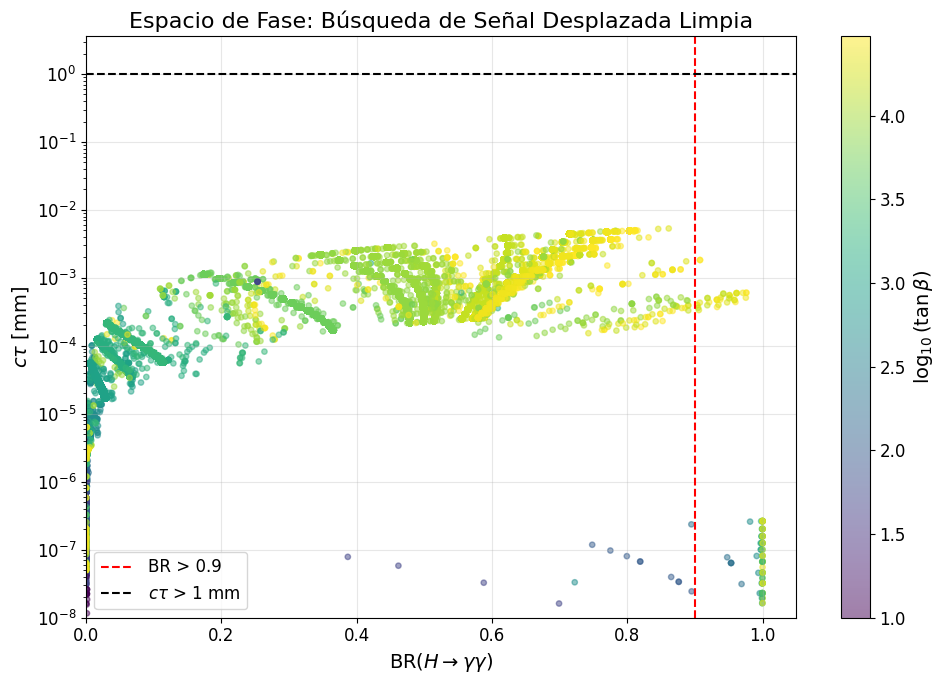

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

# Coloreamos por tan_beta para ver qué valor nos lleva al sweet spot
sc = ax.scatter(
    df_valid["br_gaga"], 
    df_valid["ctau_mm"], 
    c=np.log10(df_valid["tan_beta"]), 
    cmap='viridis', 
    alpha=0.5,
    s=15
)

cbar = plt.colorbar(sc)
cbar.set_label(r'$\log_{10}(\tan\beta)$', fontsize=14)

# Región Objetivo
ax.axvline(0.9, color='r', linestyle='--', label='BR > 0.9')
ax.axhline(1.0, color='k', linestyle='--', label=r'$c\tau$ > 1 mm')

# Etiquetas y Límites
ax.set_xlabel(r'BR($H \to \gamma\gamma$)', fontsize=14)
ax.set_ylabel(r'$c\tau$ [mm]', fontsize=14)
ax.set_yscale('log')
ax.set_xlim(0.0, 1.05) 
# Ajusta el límite Y según tus datos (ej. 1e-3 a 1e4)
ax.set_ylim(bottom=1e-8) 

ax.set_title("Espacio de Fase: Búsqueda de Señal Desplazada Limpia", fontsize=16)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- que ocurre aqui?

más dimensiones, necesitamos saber si algunos valores de $m_\phi$ son los que limitan Zga y provocan BR tan altos

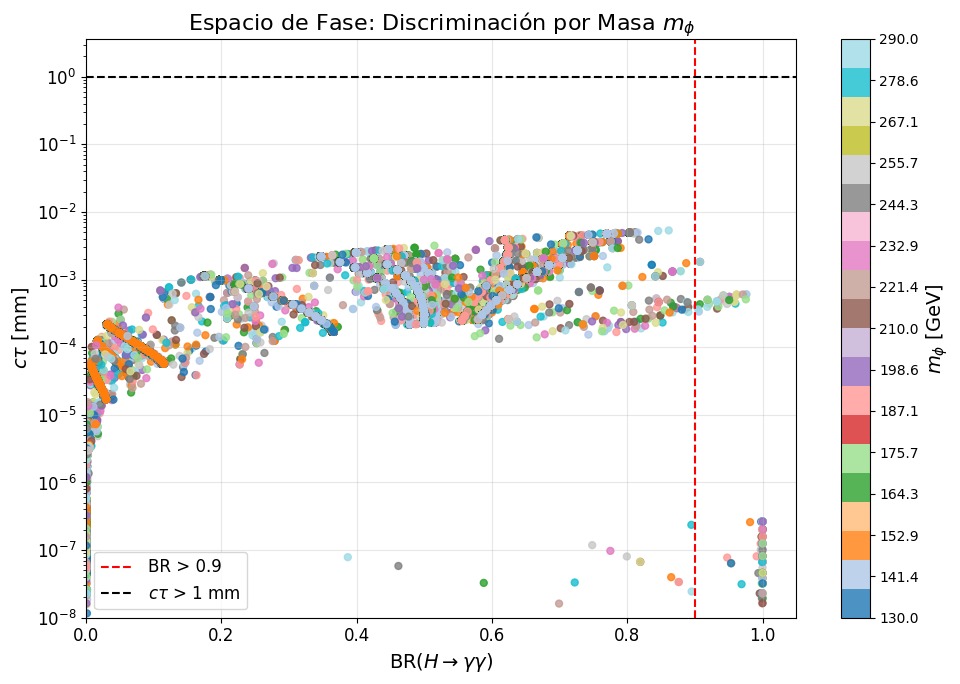

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

# Usamos 'tab20' para distinguir las 15 masas discretas claramente
sc = ax.scatter(
    df_valid["br_gaga"], 
    df_valid["ctau_mm"], 
    c=df_valid["m_phi"], 
    cmap='tab20', 
    alpha=0.8,
    s=25
)

# Barra de colores discreta
# Identificamos los valores únicos para los ticks
unique_masses = np.sort(df_valid["m_phi"].unique())
cbar = plt.colorbar(sc, ticks=unique_masses)
cbar.set_label(r'$m_\phi$ [GeV]', fontsize=14)
cbar.ax.tick_params(labelsize=10) 

# Región Objetivo (mantenemos referencias del original)
ax.axvline(0.9, color='r', linestyle='--', label='BR > 0.9')
ax.axhline(1.0, color='k', linestyle='--', label=r'$c\tau$ > 1 mm')

# Etiquetas y Límites
ax.set_xlabel(r'BR($H \to \gamma\gamma$)', fontsize=14)
ax.set_ylabel(r'$c\tau$ [mm]', fontsize=14)
ax.set_yscale('log')
ax.set_xlim(0.0, 1.05) 
ax.set_ylim(bottom=1e-8) 

ax.set_title(r"Espacio de Fase: Discriminación por Masa $m_\phi$", fontsize=16)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

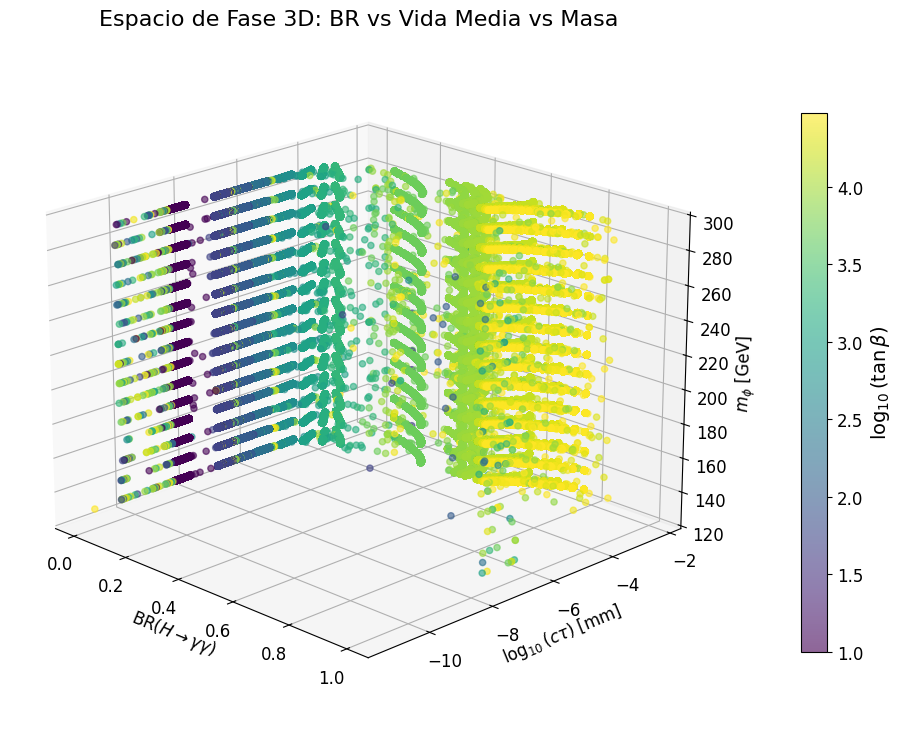

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Variables para los ejes
xs = df_valid["br_gaga"]
ys = np.log10(df_valid["ctau_mm"]) # Usamos log10 para linealizar la visualización en 3D
zs = df_valid["m_phi"]
colors = np.log10(df_valid["tan_beta"])

# Gráfico de dispersión 3D
p = ax.scatter(xs, ys, zs, c=colors, cmap='viridis', alpha=0.6, s=20)

# Barra de colores para tan_beta
cbar = fig.colorbar(p, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label(r'$\log_{10}(\tan\beta)$', fontsize=14)

# Etiquetas
ax.set_xlabel(r'BR($H \to \gamma\gamma$)', fontsize=12)
ax.set_ylabel(r'$\log_{10}(c\tau)$ [mm]', fontsize=12)
ax.set_zlabel(r'$m_\phi$ [GeV]', fontsize=12)

# Ajuste de vista inicial (opcional, elevación y azimut)
ax.view_init(elev=20, azim=-45)

ax.set_title("Espacio de Fase 3D: BR vs Vida Media vs Masa", fontsize=16)
plt.show()

## Hipotesis cinematica Zga

In [8]:
# 1. Filtrar la región de BR anómalamente alto
umbral_br = 0.95
df_high_br = df_valid[df_valid["br_gaga"] > umbral_br].copy()

# 2. Calcular Gamma_tot (GeV) desde ctau (mm) si no existe la columna
# constante hbar_c ~= 1.97327e-13 mm*GeV
if "total_width_GeV" not in df_high_br.columns:
    hbar_c_mm_gev = 1.97327e-13
    df_high_br["total_width_GeV"] = hbar_c_mm_gev / df_high_br["ctau_mm"]

print(f"--- DIAGNÓSTICO RÁPIDO (BR > {umbral_br}) ---")
print(f"Puntos detectados: {len(df_high_br)} de {len(df_valid)}")
print("\nEstadísticas de Parámetros Físicos en esta región:")
# Agrega 'm12_2' o 'sin_ba' si están disponibles en tu DF
cols_to_inspect = ["m_phi", "tan_beta", "ctau_mm", "total_width_GeV"]
# Filtramos solo las columnas que realmente existen para evitar errores
cols_existentes = [c for c in cols_to_inspect if c in df_high_br.columns]
print(df_high_br[cols_existentes].describe())

print("\n--- Chequeo de correlación rápida ---")
print(f"Masa promedio: {df_high_br['m_phi'].mean():.2f} GeV")
print(f"Tan_beta promedio: {df_high_br['tan_beta'].mean():.2f}")

--- DIAGNÓSTICO RÁPIDO (BR > 0.95) ---
Puntos detectados: 109 de 822775

Estadísticas de Parámetros Físicos en esta región:
            m_phi      tan_beta       ctau_mm  total_width_GeV
count  109.000000    109.000000  1.090000e+02     1.090000e+02
mean   212.516384  11392.660550  7.016089e-05     3.178886e-06
std     48.620775   9805.636195  1.844475e-04     3.118634e-06
min    130.000000    200.000000  1.641288e-08     3.257337e-10
25%    175.714300   2000.000000  4.571902e-08     9.748259e-07
50%    210.000000   9000.000000  1.005701e-07     1.962084e-06
75%    255.714300  20000.000000  2.024228e-07     4.316081e-06
max    290.000000  30000.000000  6.057923e-04     1.202269e-05

--- Chequeo de correlación rápida ---
Masa promedio: 212.52 GeV
Tan_beta promedio: 11392.66


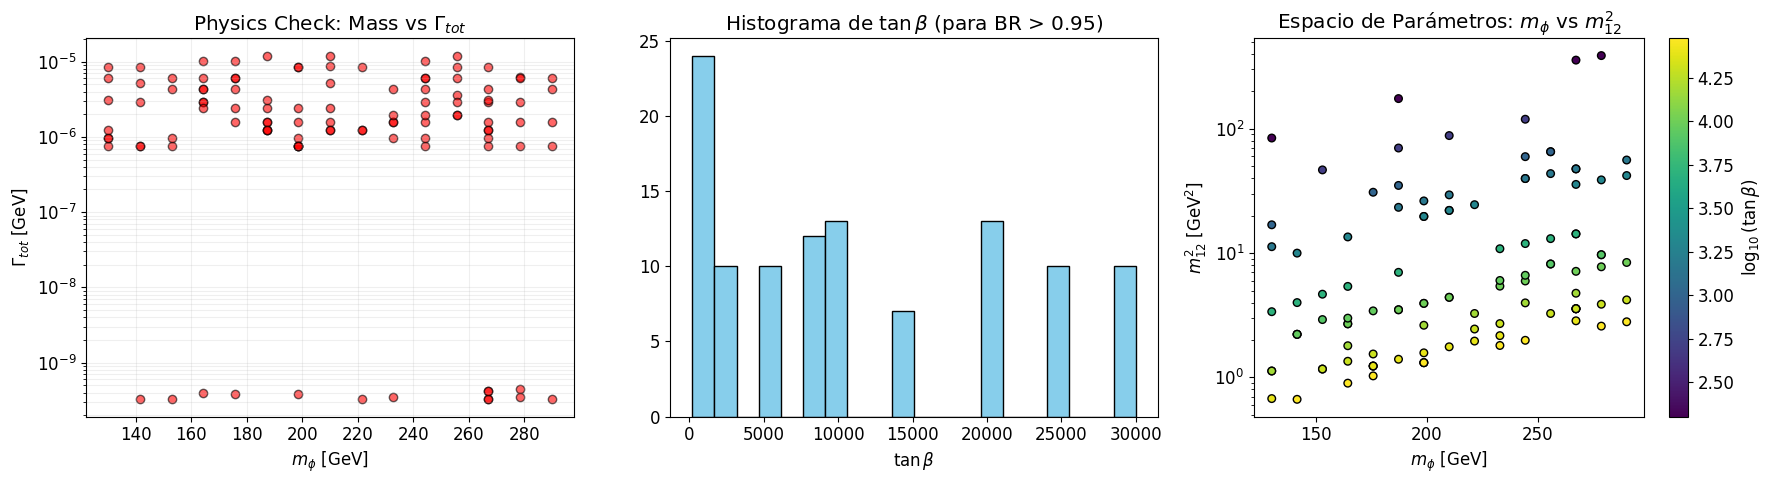

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Masa vs Anchura Total (Log)
# Si BR ~ 1, Gamma debe ser minúscula. Verificamos eso.
axes[0].scatter(df_high_br["m_phi"], df_high_br["total_width_GeV"], c='r', alpha=0.6, edgecolors='k')
axes[0].set_yscale('log')
axes[0].set_title(r"Physics Check: Mass vs $\Gamma_{tot}$")
axes[0].set_xlabel(r"$m_\phi$ [GeV]")
axes[0].set_ylabel(r"$\Gamma_{tot}$ [GeV]")
axes[0].grid(True, which="both", ls="-", alpha=0.2)

# Plot 2: Distribución de Tan Beta en estos puntos
# Buscamos si esto ocurre solo a tan_beta alto (supresión de couplings down-type)
axes[1].hist(df_high_br["tan_beta"], bins=20, color='skyblue', edgecolor='black')
axes[1].set_title(r"Histograma de $\tan\beta$ (para BR > 0.95)")
axes[1].set_xlabel(r"$\tan\beta$")

# Plot 3: Scatter 3D simplificado 2D con color
# Para ver si m12 tiene algo que ver (si la columna existe)
if "m12" in df_high_br.columns:
    sc = axes[2].scatter(
        df_high_br["m_phi"], 
        df_high_br["m12"], 
        c=np.log10(df_high_br["tan_beta"]), 
        cmap='viridis', 
        s=30,
        edgecolors='k'
    )
    axes[2].set_yscale('log')
    cbar = plt.colorbar(sc, ax=axes[2])
    cbar.set_label(r'$\log_{10}(\tan\beta)$')
    axes[2].set_ylabel(r"$m_{12}^2$ [GeV$^2$]")
else:
    # Fallback si no hay m12
    axes[2].text(0.5, 0.5, "Variable m12 no encontrada", ha='center')

axes[2].set_title(r"Espacio de Parámetros: $m_\phi$ vs $m_{12}^2$")
axes[2].set_xlabel(r"$m_\phi$ [GeV]")

plt.tight_layout()
plt.show()

/tmp/ipykernel_15614/864201770.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high["total_width_GeV"] = hbar_c_mm_gev / df_high["ctau_mm"]
/tmp/ipykernel_15614/864201770.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_low["total_width_GeV"] = hbar_c_mm_gev / df_low["ctau_mm"]
/tmp/ipykernel_15614/864201770.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/fabi/higgs_env_py312/lib/python3.12/site-packages/IPython/core/pylab

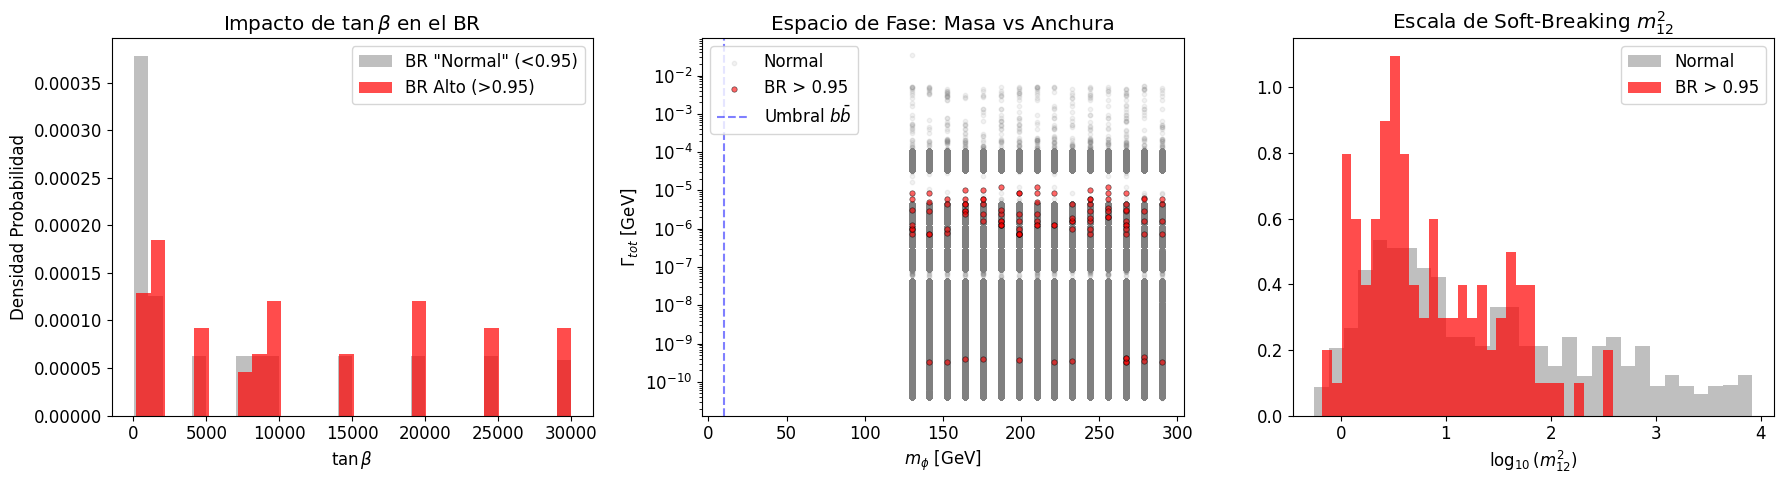

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Separar las poblaciones
df_high = df_valid[df_valid["br_gaga"] > 0.95]
df_low  = df_valid[df_valid["br_gaga"] <= 0.95]

# Calcular Gamma_tot si no existe (GeV)
hbar_c_mm_gev = 1.97327e-13
if "total_width_GeV" not in df_high.columns:
    df_high["total_width_GeV"] = hbar_c_mm_gev / df_high["ctau_mm"]
if "total_width_GeV" not in df_low.columns:
    df_low["total_width_GeV"] = hbar_c_mm_gev / df_low["ctau_mm"]

# 2. Configurar Gráficos Comparativos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Histograma de tan_beta (¿Es un efecto de acoplamiento?) ---
# Usamos densidad=True para comparar formas, ya que las cantidades de puntos son muy distintas
axes[0].hist(df_low["tan_beta"], bins=30, density=True, 
             alpha=0.5, color='gray', label='BR "Normal" (<0.95)')
axes[0].hist(df_high["tan_beta"], bins=30, density=True, 
             alpha=0.7, color='red',  label='BR Alto (>0.95)')
axes[0].set_xlabel(r"$\tan\beta$")
axes[0].set_ylabel("Densidad Probabilidad")
axes[0].set_title(r"Impacto de $\tan\beta$ en el BR")
axes[0].legend()

# --- Plot 2: Scatter Masa vs Ancho (¿Es cinemática?) ---
# Mostramos el "fondo" gris y los puntos "rojos" encima
axes[1].scatter(df_low["m_phi"], df_low["total_width_GeV"], 
                color='gray', alpha=0.1, s=10, label='Normal')
axes[1].scatter(df_high["m_phi"], df_high["total_width_GeV"], 
                color='red', alpha=0.6, s=15, edgecolor='k', linewidth=0.5, label='BR > 0.95')

axes[1].set_yscale('log')
axes[1].set_xlabel(r"$m_\phi$ [GeV]")
axes[1].set_ylabel(r"$\Gamma_{tot}$ [GeV]")
axes[1].set_title("Espacio de Fase: Masa vs Anchura")
# Dibujar línea umbral bb (aprox 10 GeV) para referencia física
axes[1].axvline(10.0, color='blue', linestyle='--', alpha=0.5, label=r'Umbral $b\bar{b}$')
axes[1].legend()

# --- Plot 3: Distribución de m12^2 (¿Es desacople?) ---
if "m12" in df_valid.columns:
    var_name = "m12"
    label_x = r"$m_{12}^2$ [GeV$^2$]"
    # Filtrar log positivo para evitar errores si hay negativos
    data_low = df_low[df_low[var_name] > 0][var_name]
    data_high = df_high[df_high[var_name] > 0][var_name]
    
    axes[2].hist(np.log10(data_low), bins=30, density=True,
                 alpha=0.5, color='gray', label='Normal')
    axes[2].hist(np.log10(data_high), bins=30, density=True,
                 alpha=0.7, color='red', label='BR > 0.95')
    axes[2].set_xlabel(r"$\log_{10}(m_{12}^2)$")
    axes[2].set_title(r"Escala de Soft-Breaking $m_{12}^2$")
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, "m12 no disponible", ha='center')

plt.tight_layout()
plt.show()

## TODO
-[ ] explorar por que hay puntos con BR tan altos, y por que no compiten contra $Z\gamma$
    - precisamente como se componen esas variables

In [15]:
df_high.columns

Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5',
       'ctau_mm', 'total_width_GeV'],
      dtype='object')

(array([33., 25., 16.,  8.,  2., 11.,  0.,  8.,  3.,  3.]),
 array([3.17484100e-10, 1.20206374e-06, 2.40380999e-06, 3.60555624e-06,
        4.80730249e-06, 6.00904874e-06, 7.21079499e-06, 8.41254125e-06,
        9.61428750e-06, 1.08160337e-05, 1.20177800e-05]),
 <BarContainer object of 10 artists>)

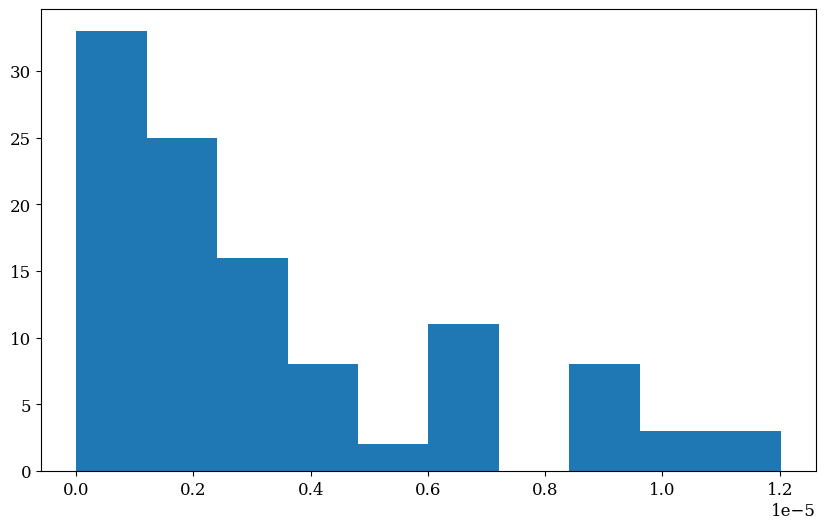

In [19]:
plt.hist(df_high.width_gaga)

[]

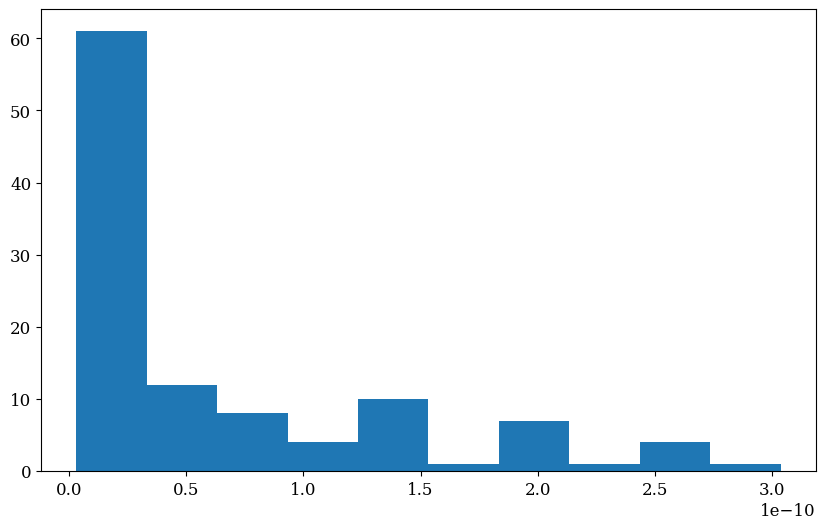

In [18]:
plt.hist(df_high.width_Zga)
# plt.hist(df_high.width_bb)
plt.plot()

## impacto de $\lambda_1$

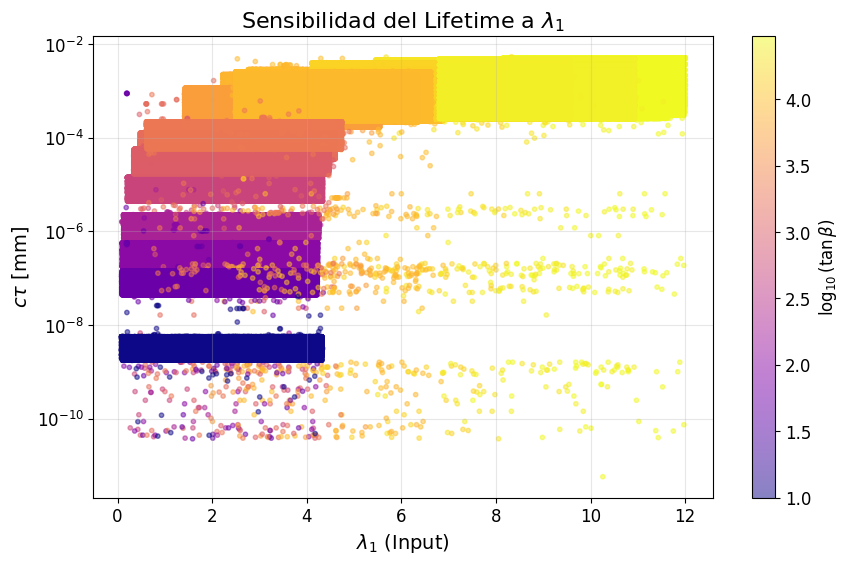

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    df_valid["lam1"], 
    df_valid["ctau_mm"], 
    c=np.log10(df_valid["tan_beta"]), 
    cmap='plasma', 
    alpha=0.5,
    s=10
)
cbar = plt.colorbar(sc)
cbar.set_label(r'$\log_{10}(\tan\beta)$', fontsize=12)

ax.set_xlabel(r'$\lambda_1$ (Input)', fontsize=14)
ax.set_ylabel(r'$c\tau$ [mm]', fontsize=14)
ax.set_yscale('log')
ax.set_title(r"Sensibilidad del Lifetime a $\lambda_1$", fontsize=16)
ax.grid(True, alpha=0.3)

plt.show()

## Relación entre $Z\gamma$ y $\gamma\gamma$

In [12]:
# ==========================================
# 10. EVOLUCIÓN MULTI-MASA DE BRANCHING RATIOS
# ==========================================
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- PARAMETROS DE CONTROL DE VISUALIZACIÓN ---
MASSES_TO_PLOT = [140, 180, 220, 260] # Masas representativas (GeV)
MASS_TOLERANCE = 5.0                  # Ventana de tolerancia para seleccionar puntos (GeV)
Y_LIMITS       = (1e-4, 1.3)          # Rango del eje Y (Branching Ratio)
X_LIMITS       = (10, 5000)           # Rango del eje X (TanBeta)
FIG_SIZE       = (18, 12)             # Tamaño total de la figura
FONT_SIZE      = 12                   # Tamaño base de fuente
SHOW_GRID_MINOR= True                 # Mostrar grid secundario

# Colores y Estilos (Diccionario para consistencia)
STYLES = {
    'bb':   {'color': 'gray',    'ls': ':',  'lw': 2.0, 'label': r'$b\bar{b}$'},
    'WW':   {'color': 'orange',  'ls': '--', 'lw': 1.5, 'label': r'$WW$'},
    'ZZ':   {'color': 'green',   'ls': '--', 'lw': 1.5, 'label': r'$ZZ$'},
    'hh':   {'color': 'purple',  'ls': '-.', 'lw': 2.0, 'label': r'$hh$'},
    'Zga':  {'color': 'darkred', 'ls': '--', 'lw': 2.0, 'label': r'$Z\gamma$'},
    'gaga': {'color': 'red',     'ls': '-',  'lw': 3.5, 'label': r'$\gamma\gamma$ (Signal)'}
}

# Configuración Global
plt.rcParams.update({'font.size': FONT_SIZE, 'font.family': 'serif'})

# Verificar datos
if 'df_audit' not in locals() or df_audit.empty:
    print("[ERROR] 'df_audit' no está cargado. Ejecuta la celda de carga de datos primero.")
else:
    # Crear layout dinámico (2x2)
    n_plots = len(MASSES_TO_PLOT)
    rows = 2
    cols = 2
    fig, axes = plt.subplots(rows, cols, figsize=FIG_SIZE, sharex=True, sharey=True)
    axes = axes.flatten()

    for i, m_target in enumerate(MASSES_TO_PLOT):
        ax = axes[i] if i < len(axes) else None
        if ax is None: break

        # 1. Filtrar Datos para esta masa
        subset = df_audit[ 
            (df_audit["m_phi"] > m_target - MASS_TOLERANCE) & 
            (df_audit["m_phi"] < m_target + MASS_TOLERANCE) 
        ].copy()

        if subset.empty:
            ax.text(0.5, 0.5, f"No data for {m_target} GeV", ha='center', transform=ax.transAxes)
            continue

        # 2. Suavizado (Binning por TanBeta)
        bins = np.logspace(np.log10(subset["tan_beta"].min()), np.log10(subset["tan_beta"].max()), 40)
        subset["tb_bin"] = pd.cut(subset["tan_beta"], bins)
        grouped = subset.groupby("tb_bin", observed=True).mean(numeric_only=True)
        x_vals = [interval.mid for interval in grouped.index]

        # 3. Plotting de Canales
        # Backgrounds
        ax.plot(x_vals, grouped["BR_bb"], **STYLES['bb'], alpha=0.6)
        ax.plot(x_vals, grouped["BR_WW"], **STYLES['WW'], alpha=0.6)
        ax.plot(x_vals, grouped["BR_ZZ"], **STYLES['ZZ'], alpha=0.6)
        
        # Competencia Escalar
        # Solo graficar hh si tiene valores significativos (para no ensuciar el plot a baja masa)
        if grouped["BR_hh"].max() > 1e-3:
            ax.plot(x_vals, grouped["BR_hh"], **STYLES['hh'], alpha=0.7)

        # Loops
        ax.plot(x_vals, grouped["BR_Zga"], **STYLES['Zga'], alpha=0.7)
        ax.plot(x_vals, grouped["BR_gaga"], **STYLES['gaga'], zorder=10) # Signal on top

        # 4. Decoración Específica
        ax.set_title(r'$m_H \approx ' + str(m_target) + r'$ GeV', fontsize=FONT_SIZE+2, fontweight='bold')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylim(Y_LIMITS)
        ax.set_xlim(X_LIMITS)
        
        # Grid
        ax.grid(True, which="major", ls="-", alpha=0.4)
        if SHOW_GRID_MINOR:
            ax.grid(True, which="minor", ls=":", alpha=0.2)

        # Zona de Dominancia (>90%)
        ax.axhspan(0.9, 2.0, color='red', alpha=0.05)
        ax.axhline(0.9, color='red', linestyle=':', linewidth=1)

        # Texto de Umbral Fermiofóbico
        # Encontrar cruce bb vs gaga
        try:
            diff = grouped["BR_gaga"] - grouped["BR_bb"]
            cross_idx = np.where(np.diff(np.sign(diff)))[0]
            if len(cross_idx) > 0:
                cross_x = x_vals[cross_idx[0]]
                ax.axvline(cross_x, color='gray', linestyle=':', alpha=0.5)
                # Solo poner texto en el primer plot para no saturar
                if i == 0:
                    ax.text(cross_x*1.1, 2e-4, r'$\tan\beta_{cross}$', color='gray', rotation=90, verticalalignment='bottom')
        except: pass

    # Decoración Global (Ejes compartidos)
    # Solo etiquetas en bordes exteriores
    for ax in axes[-cols:]:
        ax.set_xlabel(r'$\tan\beta$', fontsize=FONT_SIZE+2)
    
    for ax in axes[::cols]:
        ax.set_ylabel(r'Branching Ratio $\mathcal{B}(H \to X)$', fontsize=FONT_SIZE+2)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

    # Leyenda Global (Una sola para todos)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
               ncol=6, frameon=False, fontsize=FONT_SIZE)

    plt.tight_layout()
    plt.show()
    print("[INFO] Gráfico generado. Observa cómo Zgamma (rojo oscuro) imita a Gaga (rojo brillante).")

[ERROR] 'df_audit' no está cargado. Ejecuta la celda de carga de datos primero.


## Reporte final y exports

In [13]:
# Definición del Sweet Spot
br_target = 0.5

sweet_spot = df_valid[
    (df_valid["br_gaga"] > br_target) & 
    (df_valid["ctau_mm"] > 1.0) &
    (df_valid["ctau_mm"] < 7000.0) # < 7m para estar dentro del detector
].copy()

print("="*60)
print("       REPORTE DE RESULTADOS")
print("="*60)

if not sweet_spot.empty:
    print(f"Puntos Candidatos Encontrados: {len(sweet_spot)}")
    
    # Rangos óptimos
    tb_min = sweet_spot['tan_beta'].min()
    tb_max = sweet_spot['tan_beta'].max()
    m_min  = sweet_spot['m_phi'].min()
    m_max  = sweet_spot['m_phi'].max()
    ct_min = sweet_spot['ctau_mm'].min()
    ct_max = sweet_spot['ctau_mm'].max()
    
    print(f"\nRango Operativo Sugerido:")
    print(f" - TanBeta: [{tb_min:.1f}, {tb_max:.1f}]")
    print(f" - Masa H:  [{m_min:.1f}, {m_max:.1f}] GeV")
    print(f" - ctau:    [{ct_min:.3f}, {ct_max:.1f}] mm")
    
    # Análisis de lambda1 en la región ganadora
    l1_min = sweet_spot['lam1'].min()
    l1_max = sweet_spot['lam1'].max()
    print(f" - Lambda1 necesario: [{l1_min:.2f}, {l1_max:.2f}]")

    # Guardar
    outfile = f"{OUTPUT_DIR}/sweet_spot_candidates.csv"
    sweet_spot.to_csv(outfile, index=False)
    print(f"\n[EXPORT] Candidatos guardados en: {outfile}")
    
    # Histograma rápido de los TanBeta ganadores
    plt.figure(figsize=(6,4))
    plt.hist(sweet_spot["tan_beta"], bins=20, color='teal', alpha=0.7)
    plt.xlabel(r"$\tan\beta$")
    plt.title("Distribución de TanBeta en el Sweet Spot")
    plt.show()
    
else:
    print(f"[FAIL] No hay puntos que cumplan BR > {br_target} y ctau > 1mm simultáneamente.")
    print("Revisa los gráficos anteriores para ver cuán lejos estamos.")

       REPORTE DE RESULTADOS
[FAIL] No hay puntos que cumplan BR > 0.5 y ctau > 1mm simultáneamente.
Revisa los gráficos anteriores para ver cuán lejos estamos.
